<a href="https://colab.research.google.com/github/natalipro12/MydataprogectsAPI/blob/main/Copy_of_TM_Marketing_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#   Dashboard for  Marketing research  of TM registrations for parfum suplier
` *parfum manufacturer searching expansion for new markets  , need  geografical and  numerical incites for  future marketing  campagines*
*   Total registered and filled TM  worldvide
*   Top 10 countries (most active markets)
  *  Total registrations   finalised and filled incide   country
*  worldwide TM total registrations segmentation
*    5  Most active months with  registered TM
*  List of  Countries registered  new TM in April

**Vizualization**
* Geographical Distribution of Trade Mark Offices,2026  
* Top 10   TM Registration per Month '
* Top 10 Countries: Trademark Status (rlf) by Office

**Trademark Registration Marketing Dashboard**






# Data proccesing

*  Data scrapping from [EUPIN]https://www.euipn.org/en)
*   CREate one combined  EXEL ,  clean and prepare for CSV transformation
*   Data exploration and preparation
*  Split column Last office data update  for  TEXT and data
 *  drop duplicates   

*  Extract valuable incites
1.  Trade mark office abbreviation
2. Trade mark status  count /   %     TOTAL ,2026
3. Total registrations/Top 10 countries
4. TM count distribution,Group countries by Regions.Vizualization
5. Registered TM per month,sorted by activity
6. Countries registered in April
7. Trade mark status for 'FR' office
8. Combined Vizualization per country ,2026







*Split column Last office data update  for  TEXT and data *

*Load libroaries and read CSV*

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TMV.csv to TMV.csv


In [ ]:

#IMPORTING LIBRARIES
import pandas as pd
import statistics as stats
import numpy as np
import matplotlib.pyplot as pl
import seaborn as sns

In [ ]:
df= pd.read_csv('TMV.csv')
display(df.head())

,Trade mark office,Trade mark status,Registration date,Last office data update,Unnamed: 4
0,EM,Registered,27-05-2026,EUIPO - 17.06.2026,NaN
1,EM,Filed,NaN,EUIPO - 17.06.2026,NaN
2,UA,Filed,NaN,Ukraine - 13.06.2026,NaN
3,FR,Filed,NaN,France - 17.06.2026,NaN
4,UA,Filed,NaN,Ukraine - 13.06.2026,NaN


### Splitting 'Last office data update' and converting 'Date'



In [ ]:
split_data = df['Last office data update'].str.split(' - ', expand=True)
df['Office'] = split_data[0]  # First part is the office name
df['Date'] = split_data[1]   # Second part is the date

In [ ]:
print(df.columns.tolist())

['Trade mark office', 'Trade mark status', 'Registration date', 'Last office data update', 'Unnamed: 4', 'Office', 'Date']


In [ ]:
df.drop(columns=['Last office data update', 'Unnamed: 4'], inplace=True)

In [ ]:
df.head(2)

,Trade mark office,Trade mark status,Registration date,Office,Date
0,EM,Registered,27-05-2026,EUIPO,17.06.2026
1,EM,Filed,NaN,EUIPO,17.06.2026


In [ ]:
# Get unique pairs of 'Trade mark office' and 'Office'
office_mapping = df[['Trade mark office', 'Office']].drop_duplicates().sort_values(by='Trade mark office').reset_index(drop=True)

print("Mapping of 'Trade mark office' to 'Office':")
print(office_mapping)

# To specifically highlight the EM -> EUIPO relationship
print("\nUnique 'Office' values associated with 'Trade mark office' EM:")
print(df[df['Trade mark office'] == 'EM']['Office'].unique())

# Also printing all unique values as requested
print("\nAll unique 'Trade mark office' values:")
print(df['Trade mark office'].unique())

print("\nAll unique 'Office' values:")
print(df['Office'].unique())

Mapping of 'Trade mark office' to 'Office':
   Trade mark office          Office
0                 AT         Austria
1                 AU       Australia
2                 BG        Bulgaria
3                 BX         Benelux
4                 CA          Canada
5                 CH     Switzerland
6                 CZ  Czech Republic
7                 DE         Germany
8                 EM           EUIPO
9                 ES           Spain
10                FR          France
11                GB  United Kingdom
12                GR          Greece
13                HU         Hungary
14                IS         Iceland
15                IT           Italy
16                MC          Monaco
17                MD         Moldova
18                MT           Malta
19                NZ     New Zealand
20                PT        Portugal
21                RO         Romania
22                SE          Sweden
23                UA         Ukraine
24                US   United S

In [ ]:
df.shape

(507, 5)

In [ ]:
status_counts = df['Trade mark status'].value_counts()
status_percentages = df['Trade mark status'].value_counts(normalize=True) * 100

status_df = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_percentages.round(2)
})

print("Unique counts and percentages for 'Trade mark status':")
print(status_df)

Unique counts and percentages for 'Trade mark status':
                   Count  Percentage
Trade mark status                   
Filed                277       55.07
Registered           226       44.93


*Total  registrations in db*

In [ ]:
print(df['Trade mark office'].value_counts().sum())

503


*Top 10 countries*

In [ ]:
print(df['Trade mark office'].value_counts().sort_values(ascending=False))

Trade mark office
EM    147
FR    106
US     60
WO     32
GB     30
UA     20
CA     18
ES     14
IT     12
DE     12
MT      7
RO      7
BX      7
CH      7
AU      6
NZ      3
IS      3
PT      2
HU      2
AT      2
GR      1
CZ      1
BG      1
SE      1
MC      1
MD      1
Name: count, dtype: int64


*Group countries by Geografy*

In [ ]:
def categorize_office_by_geography(office):
    eu_countries = ['EM', 'FR', 'ES', 'IT', 'DE', 'MT', 'RO', 'PT', 'HU', 'AT', 'GR', 'CZ', 'BG', 'BX']
    north_america = ['US', 'CA']

    if office in eu_countries:
        return 'EU countries'
    elif office == 'GB':
        return 'UK'
    elif office in north_america:
        return 'North America'
    elif office == 'UA':
        return 'Ukraine'
    elif pd.isna(office):
        return 'Other' # Changed from 'Unknown' to 'Other'
    else:
        return 'Other'

df['Geography'] = df['Trade mark office'].apply(categorize_office_by_geography)

print("Trade mark offices categorized by Geography:")
print(df['Geography'].value_counts())

Trade mark offices categorized by Geography:
Geography
EU countries     321
North America     78
Other             58
UK                30
Ukraine           20
Name: count, dtype: int64


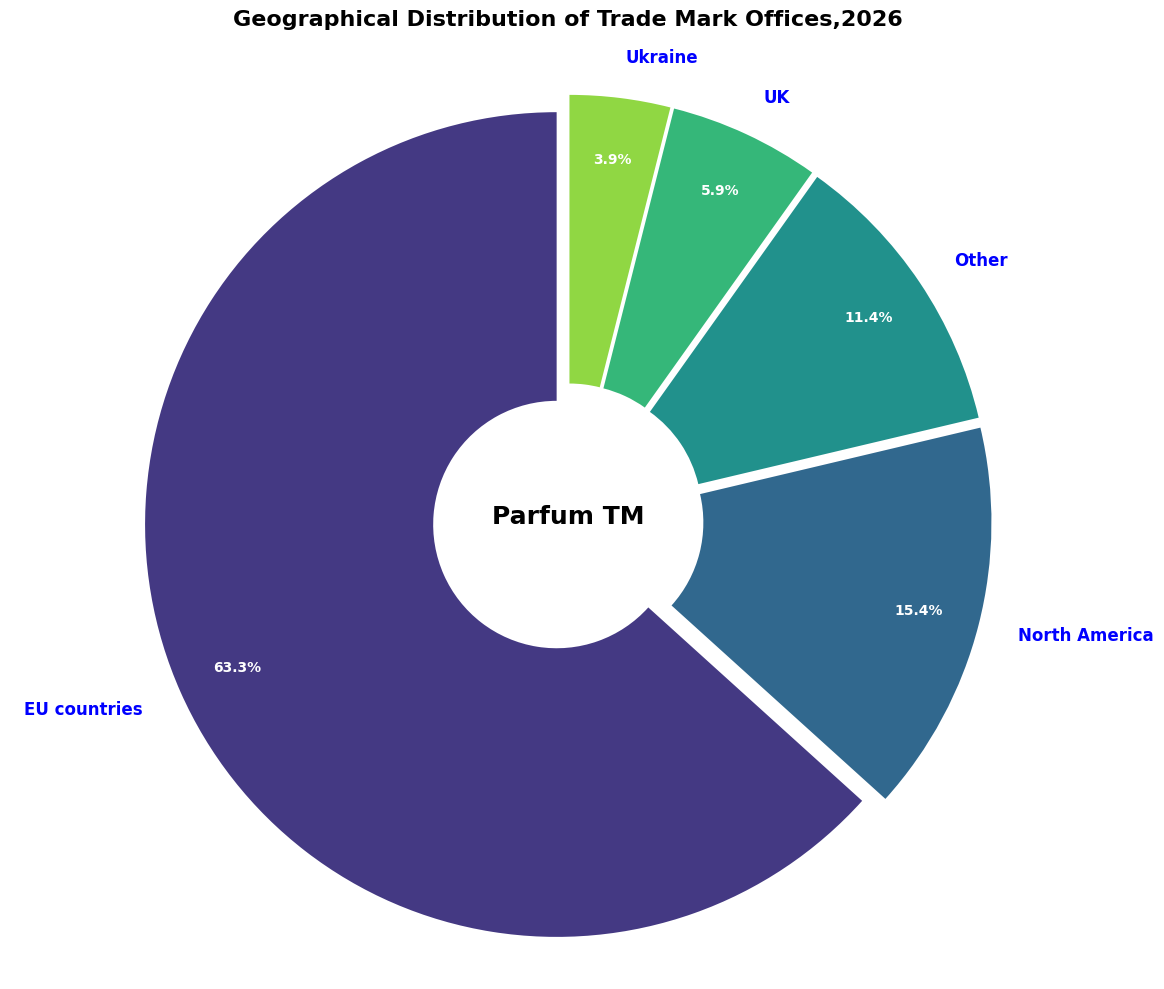

In [ ]:
import matplotlib.pyplot as pl
import seaborn as sns

# Calculate value counts for the 'Geography' column
geography_counts = df['Geography'].value_counts()

# Prepare data for plotting
labels = geography_counts.index
sizes = geography_counts.values

# Create a figure and a set of subplots
fig, ax = pl.subplots(figsize=(12, 10))

# Define colors for the segments using a seaborn palette
colors = sns.color_palette('viridis', len(labels))

# Explode a small amount to give a 'segmented' look
explode_values = [0.03] * len(labels) # Small explode for all slices

# Create the pie chart
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode_values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%', # Percentages inside sectors
    startangle=90,
    pctdistance=0.85, # Distance of percentage labels from the center
    wedgeprops=dict(width=0.7) # Adjust wedge width for a slightly segmented look
)

# Customize the titles (labels) for countries/regions to be bold and blue
for text in texts:
    text.set_color('blue')
    text.set_fontweight('bold')
    text.set_fontsize(12)

# Customize percentage labels
for autotext in autotexts:
    autotext.set_color('white') # Set a clear color for percentages inside segments
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Geographical Distribution of Trade Mark Offices,2026', fontsize=16, fontweight='bold', pad=20)

# Add 'Parfum TM' text in the center of the pie chart
ax.text(0.5, 0.5, 'Parfum TM', horizontalalignment='center', verticalalignment='center',
        fontsize=18, color='black', fontweight='bold', transform=ax.transAxes)

pl.tight_layout()
pl.show()

*Total registratins in 2026*

In [ ]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')

monthly_registrations = df['Date'].dt.to_period('M').value_counts().sort_index()
print("Registered in 2026 :")
print(monthly_registrations)

Registered in 2026 :
Date
2026-06    503
Freq: M, Name: count, dtype: int64


* Registered TM    per month*

In [ ]:
df['Registration date'] = pd.to_datetime(df['Registration date'], format='%d-%m-%Y', errors='coerce')

# Count unique registration dates per month
unique_registration_per_month = df.groupby(df['Registration date'].dt.to_period('M'))['Registration date'].nunique()

print("Unique registration entries per month:")
print(unique_registration_per_month.sort_values(ascending=False))

Unique registration entries per month:
Registration date
2026-05    14
2025-12    13
2026-03    12
2026-04    12
2026-02     9
2025-11     7
2025-09     6
2026-01     6
2026-06     6
2025-10     5
2025-08     4
2025-07     1
2025-04     1
Freq: M, Name: Registration date, dtype: int64


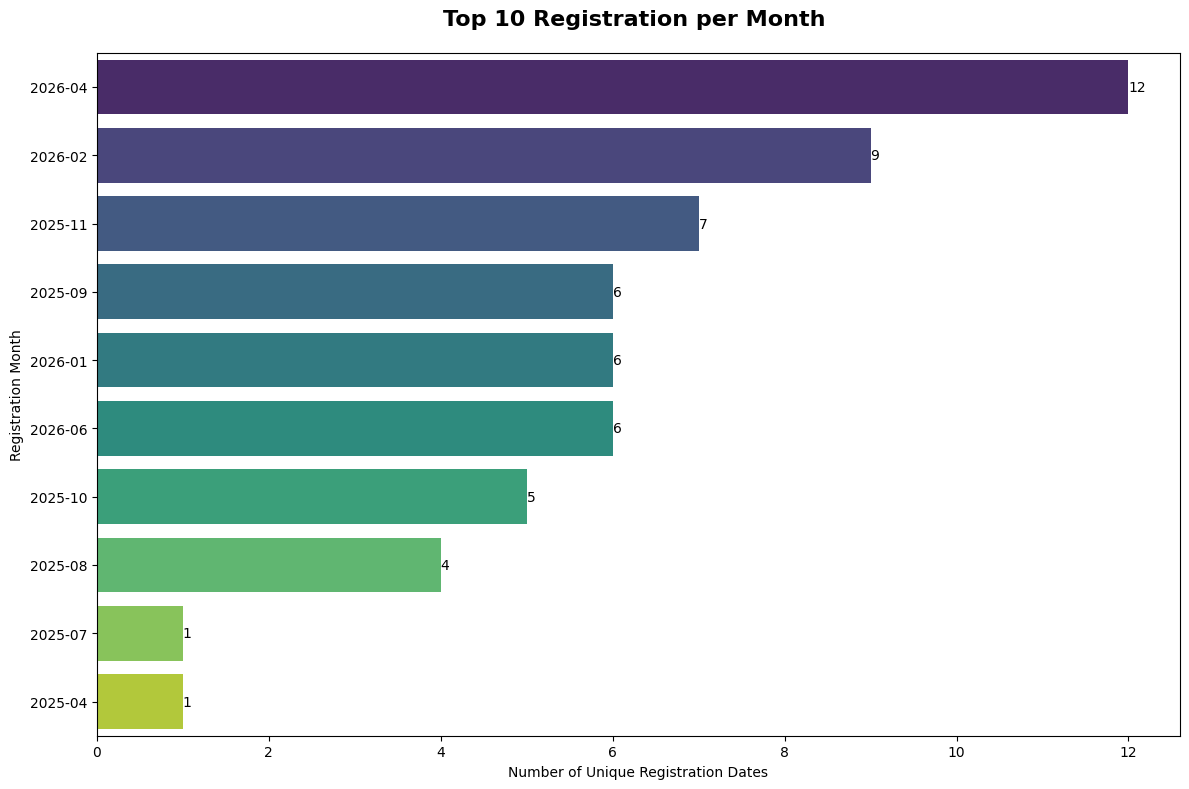

In [ ]:
# Sort the unique registration entries per month in ascending order and get the top 10
top_10_unique_registration_per_month = unique_registration_per_month.sort_values(ascending=False).tail(10)

# Create a horizontal bar chart
fig, ax = pl.subplots(figsize=(12, 8))

sns.barplot(
    x=top_10_unique_registration_per_month.values,
    y=top_10_unique_registration_per_month.index.astype(str),
    palette='viridis',
    ax=ax,
    orient='h',
    hue=top_10_unique_registration_per_month.index.astype(str),
    legend=False
)

ax.set_title('Top 10 Registration per Month ', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Unique Registration Dates')
ax.set_ylabel('Registration Month')

# Add count numbers on each bar
for index, value in enumerate(top_10_unique_registration_per_month.values):
    ax.text(value, index, str(value), va='center')

pl.tight_layout()
pl.show()

In [ ]:
# Filter the DataFrame for registrations in April
april_registrations = df[df['Registration date'].dt.month == 4]

# Get the unique 'Trade mark office' for April registrations
unique_offices_april = april_registrations['Trade mark office'].unique()

print("Countries registered in April:")
if len(unique_offices_april) > 0:
    for office in unique_offices_april:
        print(office)
else:
    print("No registrations found for April.")

Countries registered in April:
ES
EM
FR
MT
CH
DE
GB
US


*TM status  for  country FR*

In [ ]:
fr_office_data = df[df['Trade mark office'] == 'FR']
fr_status_counts = fr_office_data['Trade mark status'].value_counts()

print("Trade mark status for 'FR' office:")
print(fr_status_counts)

Trade mark status for 'FR' office:
Trade mark status
Registered    61
Filed         45
Name: count, dtype: int64


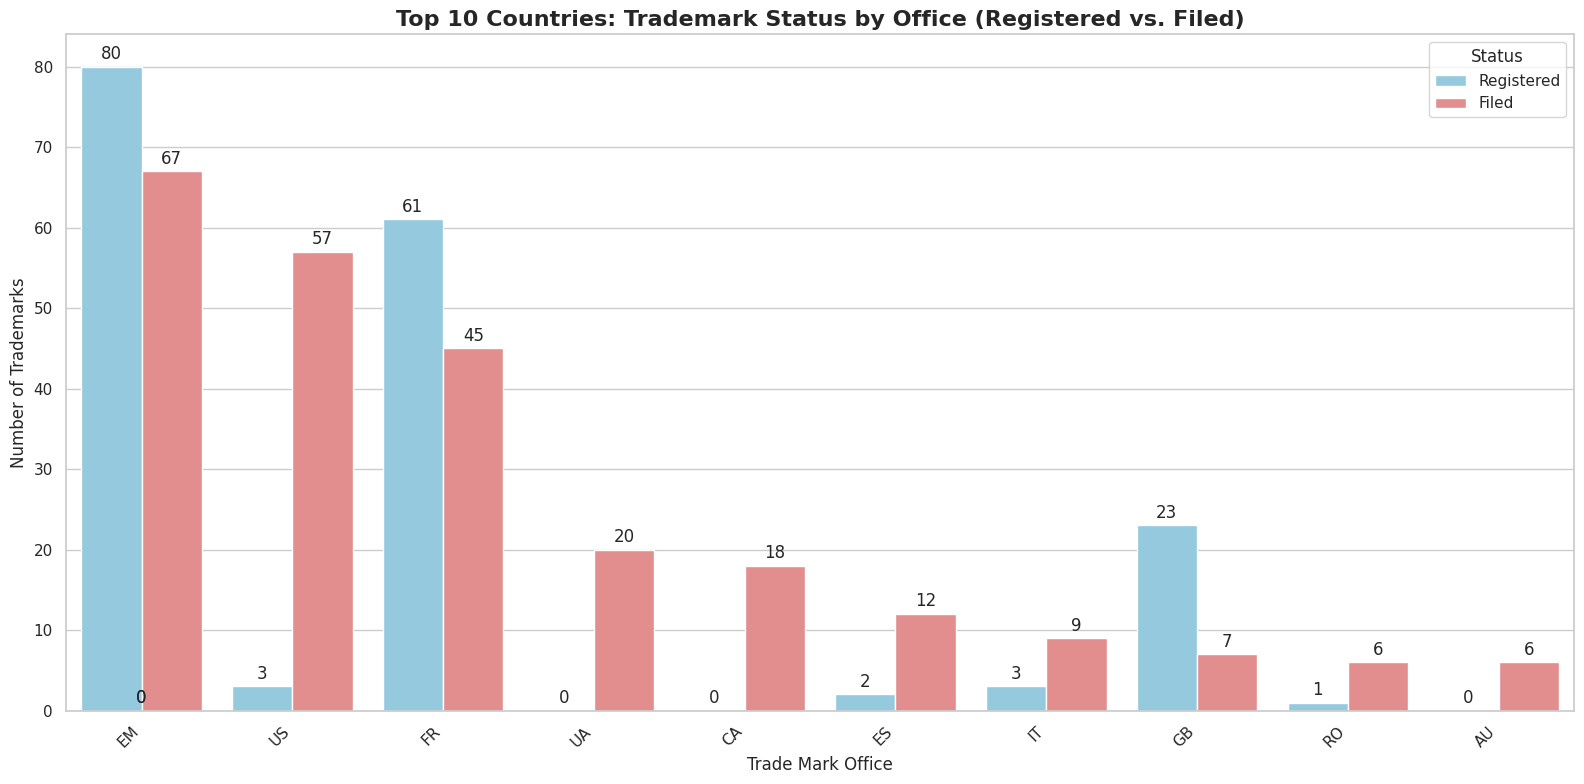

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Trade mark office' and 'Trade mark status' and count
tm_status_by_office = df.groupby(['Trade mark office', 'Trade mark status']).size().unstack(fill_value=0)

# Ensure both 'Filed' and 'Registered' columns exist, fill with 0 if not
if 'Filed' not in tm_status_by_office.columns:
    tm_status_by_office['Filed'] = 0
if 'Registered' not in tm_status_by_office.columns:
    tm_status_by_office['Registered'] = 0

# Sort by 'Filed' count in descending order and select top 10
tm_status_by_office_sorted = tm_status_by_office.sort_values(by='Filed', ascending=False).head(10)

# Reset index to make 'Trade mark office' a column for melting
tm_status_by_office_sorted = tm_status_by_office_sorted.reset_index()

# Melt the DataFrame to prepare for seaborn barplot with hue
tm_melted = tm_status_by_office_sorted.melt(id_vars='Trade mark office',
                                             value_vars=['Registered', 'Filed'],
                                             var_name='Trade mark status',
                                             value_name='Number of Trademarks')

# Create the plot
plt.figure(figsize=(16, 8)) # Adjusted figure size for vertical bars
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Trade mark office',
    y='Number of Trademarks',
    hue='Trade mark status', # Use 'Trade mark status' for coloring
    data=tm_melted,
    palette={'Registered': 'skyblue', 'Filed': 'lightcoral'}
)

# Add count numbers on each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Top 10 Countries: Trademark Status by Office (Registered vs. Filed)', fontsize=16, fontweight='bold')
plt.xlabel('Trade Mark Office', fontsize=12)
plt.ylabel('Number of Trademarks', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [ ]:
# Ensure 'Registration date' is datetime and create month options
df['Registration date'] = pd.to_datetime(df['Registration date'], errors='coerce')

# Prepare options for multiselect dropdowns
geography_options = sorted(df['Geography'].unique().tolist())
status_options = ["Filed", "Registered"] # Explicitly list statuses
month_options = sorted(df['Registration date'].dt.strftime('%Y-%m').dropna().unique().tolist())
trade_mark_office_options = sorted(df['Trade mark office'].dropna().unique().tolist())

interface = gr.Interface(
    fn=update_dashboard,
    inputs=[
        gr.Dropdown(geography_options, multiselect=True, value=geography_options, label="Select Geography"),
        gr.Dropdown(status_options, multiselect=True, value=status_options, label="Select Trade Mark Status"),
        gr.Dropdown(month_options, multiselect=True, value=month_options, label="Select Month"),
        gr.Dropdown(trade_mark_office_options, multiselect=True, value=trade_mark_office_options, label="Select Trade Mark Office")
    ],
    outputs=[
        gr.Plot(label="Filed Status Count"),
        gr.Plot(label="Registered Status Count"),
        gr.Number(label="Total Count for Selection"),
        gr.Markdown(label="Unique Offices/Countries"),
        gr.Markdown(label="Unique Trade Mark Office Abbreviations")
    ],
    title="Interactive Trade Mark Status Dashboard by Geography, Month, and Status"
)

In [ ]:
# interface.launch(share=True, debug=True) # Commented out to prevent launching multiple Gradio apps

In [ ]:
import gradio as gr
import pandas as pd
import plotly.express as px

# Ensure 'Registration date' is datetime and create month options (if not already done)
# This re-runs necessary preprocessing to ensure data readiness for this dashboard.
if 'Registration date' not in df.columns or not pd.api.types.is_datetime64_any_dtype(df['Registration date']):
    df['Registration date'] = pd.to_datetime(df['Registration date'], format='%d-%m-%Y', errors='coerce')

# Ensure 'Geography' column exists (if not already done)
# This re-runs necessary preprocessing to ensure data readiness for this dashboard.
if 'Geography' not in df.columns:
    def categorize_office_by_geography(office):
        eu_countries = ['EM', 'FR', 'ES', 'IT', 'DE', 'MT', 'RO', 'PT', 'HU', 'AT', 'GR', 'CZ', 'BG', 'BX']
        north_america = ['US','CA']

        if office in eu_countries:
            return 'EU countries'
        elif office == 'GB':
            return 'UK'
        elif office in north_america:
            return 'North America'
        elif office == 'UA':
            return 'Ukraine'
        elif pd.isna(office):
            return 'Other'
        else:
            return 'Other'
    df['Geography'] = df['Trade mark office'].apply(categorize_office_by_geography)

# Prepare options for multiselect dropdowns (re-using logic from previous cells)
geography_options = sorted(df['Geography'].dropna().unique().tolist())
status_options = sorted(df['Trade mark status'].dropna().unique().tolist()) # Dynamically get from data
month_options = sorted(df['Registration date'].dt.strftime('%Y-%m').dropna().unique().tolist())
trade_mark_office_options = sorted(df['Trade mark office'].dropna().unique().tolist())

# 2. Prepare your data and insight logic
def update_blocks_dashboard(selected_geographies, selected_statuses, selected_months, selected_office):
    global df # Access the global DataFrame

    filtered_df = df.copy()

    # Filter by selected geographies
    if selected_geographies:
        filtered_df = filtered_df[filtered_df['Geography'].isin(selected_geographies)]

    # Filter by Trade mark office
    if selected_office:
        filtered_df = filtered_df[filtered_df['Trade mark office'].isin(selected_office)]

    # Filter by selected months
    if selected_months:
        # Ensure 'Registration date' is datetime type before filtering
        filtered_df = filtered_df[filtered_df['Registration date'].dt.strftime('%Y-%m').isin(selected_months)]

    # Filter by selected statuses
    if selected_statuses:
        filtered_df = filtered_df[filtered_df['Trade mark status'].isin(selected_statuses)]

    # Calculate KPIs
    actual_filed_count = filtered_df[filtered_df['Trade mark status'] == 'Filed'].shape[0]
    actual_registered_count = filtered_df[filtered_df['Trade mark status'] == 'Registered'].shape[0]
    total_relevant_count = actual_filed_count + actual_registered_count

    # Generate Summary Metrics as HTML
    metrics_html = f"""
    <div style='display: flex; gap: 20px; font-family: sans-serif;'>
        <div style='background: #f0f2f6; padding: 15px; border-radius: 8px; flex: 1; text-align: center;'>
            <h3 style='margin: 0; color: #555;'>Total Filed TM</h3>
            <p style='font-size: 24px; font-weight: bold; margin: 5px 0 0 0;'>{actual_filed_count:,}</p>
        </div>
        <div style='background: #f0f2f6; padding: 15px; border-radius: 8px; flex: 1; text-align: center;'>
            <h3 style='margin: 0; color: #555;'>Total Registered TM</h3>
            <p style='font-size: 24px; font-weight: bold; margin: 5px 0 0 0;'>{actual_registered_count:,}</p>
        </div>
        <div style='background: #e6f7ff; padding: 15px; border-radius: 8px; flex: 1; text-align: center;'>
            <h3 style='margin: 0; color: #555;'>Total TM in Selection</h3>
            <p style='font-size: 24px; font-weight: bold; margin: 5px 0 0 0;'>{total_relevant_count:,}</p>
        </div>
    </div>
    """

    # Generate Chart: Top 10 Trade mark offices by total registrations (Filed + Registered)
    if not filtered_df.empty:
        office_counts = filtered_df.groupby('Trade mark office')['Trade mark status'].count().nlargest(10).reset_index()
        office_counts.rename(columns={'Trade mark status': 'Total Trademarks'}, inplace=True)
        fig = px.bar(
            office_counts,
            x='Trade mark office',
            y='Total Trademarks',
            color='Trade mark office',
            title=f"Top 10 Trade Mark Offices in Selected Data ({len(filtered_df)} entries)"
        )
    else:
        fig = px.bar(title="No Data for Selected Filters")

    # Return everything needed to populate the dashboard components
    return metrics_html, filtered_df, fig

# 3. Build the Dashboard Layout using Blocks
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    # Header Section
    gr.Markdown("# 📊 Trademark Registration Marketing Dashboard")
    gr.Markdown("Use the controls below to filter data insights, visual charts, and raw tables instantly.")

    # Sidebar / Control row
    with gr.Row():
        geography_dropdown = gr.Dropdown(
            choices=geography_options,
            multiselect=True,
            value=geography_options, # Select all by default
            label="Filter by Geography"
        )
        office_dropdown = gr.Dropdown(
            choices=trade_mark_office_options,
            multiselect=True,
            value=trade_mark_office_options, # Select all by default
            label="Filter by Trade Mark Office"
        )

    with gr.Row():
        status_dropdown = gr.Dropdown(
            choices=status_options,
            multiselect=True,
            value=status_options, # Select all by default
            label="Filter by Trade Mark Status"
        )
        month_dropdown = gr.Dropdown(
            choices=month_options,
            multiselect=True,
            value=month_options, # Select all by default
            label="Filter by Registration Month (YYYY-MM)"
        )

    gr.HTML("<hr>") # Visual separator

    # Live KPI Summary Row
    kpi_output = gr.HTML()

    # Content Row: Splitting Visualizations and Tables side-by-side
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📈 Trademark Activity Chart")
            plot_output = gr.Plot()

        with gr.Column(scale=1):
            gr.Markdown("### 📄 Filtered Data Ledger")
            table_output = gr.Dataframe(interactive=False)

    # 4. Map the inputs to outputs
    # This runs the logic automatically when the dashboard opens, or when any dropdown changes
    input_components = [geography_dropdown, status_dropdown, month_dropdown, office_dropdown]
    output_components = [kpi_output, table_output, plot_output]

    gr.on(
        triggers=[comp.change for comp in input_components],
        fn=update_blocks_dashboard,
        inputs=input_components,
        outputs=output_components
    )

    # Trigger on initial page load
    demo.load(
        fn=update_blocks_dashboard,
        inputs=input_components,
        outputs=output_components
    )

# 5. Launch the dashboard inside Colab
demo.launch(share=True)

/tmp/ipykernel_3660/197383882.py:101: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1678869f605110a09.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
